In [225]:
import sys
import csv
import random
import scipy
import math
import datetime
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.cluster import DBSCAN, KMeans, OPTICS
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.transforms import offset_copy
from matplotlib import ticker, cm
from mpl_toolkits.mplot3d import Axes3D


# Load the data from the CSV file
df = pd.read_csv(r'C:\Users\qdr22hqu\OneDrive - University of East Anglia\Documents\NZ EQ Clusters Ruapehu\synthetic_catalogue.csv')

df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')

start_date = '01/01/1994'
end_date = '01/01/1996'

def right(s, amount):
    return s[-4:]

start_year = (right(start_date, 4))
end_year = (right(end_date, 4))

df = df.query('date >= @start_date and date <= @end_date')

print(f"Number of earthquakes are {df['publicid'].count()}")

df

Number of earthquakes are 955


,publicid,eventtype,date,time,longitude,latitude,magnitude,depth,depth_error,mag_error,cluster
0,557548,earthquake,1994-01-15,1.014,175.66212,-39.44240,2.975,14.26,2.042,0.214,-1.0
1,558680,earthquake,1994-01-15,1.014,175.75745,-39.42632,2.918,12.81,1.561,0.264,0.0
2,550116,earthquake,1994-01-20,1.019,175.69931,-39.41895,1.886,11.61,0.873,0.042,0.0
3,548161,earthquake,1994-01-20,1.019,175.77971,-39.41813,2.638,13.52,0.159,0.210,-1.0
4,559547,earthquake,1994-01-20,1.019,175.77115,-39.39953,1.511,14.78,0.137,0.058,-1.0
...,...,...,...,...,...,...,...,...,...,...,...
950,877747,earthquake,1995-12-29,2.362,175.37770,-39.13564,1.780,4.71,0.017,0.249,NaN
951,888599,earthquake,1995-12-30,2.363,175.37051,-39.21582,1.786,16.23,1.803,0.296,NaN
952,875549,earthquake,1995-12-30,2.363,175.34840,-39.22839,2.112,13.03,0.296,0.165,NaN
953,874214,earthquake,1995-12-30,2.363,175.62117,-39.39808,1.896,11.86,0.186,0.207,NaN


In [226]:
import pyproj

# Define the NZMG projection
nzmg_proj = pyproj.Proj(proj='tmerc', lat_0='-41.0', lon_0='173.0', k='0.9996', x_0='1600000', y_0='10000000')


# Define a function to convert latitude and longitude to NZMG x and y coordinates
def convert_to_nzmg(lat, lon):
    x, y = nzmg_proj(lon, lat)
    return x, y

# Apply the conversion function to the DataFrame and create new x and y columns
df['x'], df['y'] = zip(*df.apply(lambda row: convert_to_nzmg(row['latitude'], row['longitude']), axis=1))



In [227]:
# Define the normalization function

def normalize_data(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

# Normalize the latitude and longitude columns
df['n_latitude'] = normalize_data(df['latitude'])
df['n_longitude'] = normalize_data(df['longitude'])
df['n_depth'] = normalize_data(df['depth'])
df['n_time'] = normalize_data(df['date'])


# Calculate the mean squared distance between all four parameters
mean_squared_distance = np.mean(np.square(df[['n_latitude', 'n_longitude', 'n_depth', 'n_time']].values))
print('Mean squared distance:', mean_squared_distance)


X = df[['n_latitude', 'n_longitude', 'n_depth', 'n_time']].values

print(X)

Mean squared distance: 0.32462737262401264
[[0.18723686 0.64191788 0.74505929 0.        ]
 [0.21680057 0.79861271 0.64953887 0.        ]
 [0.23035061 0.70304744 0.57048748 0.00699301]
 ...
 [0.58070269 0.12625333 0.66403162 0.9986014 ]
 [0.26872093 0.57460798 0.58695652 0.9986014 ]
 [0.03723042 0.52319274 0.828722   1.        ]]


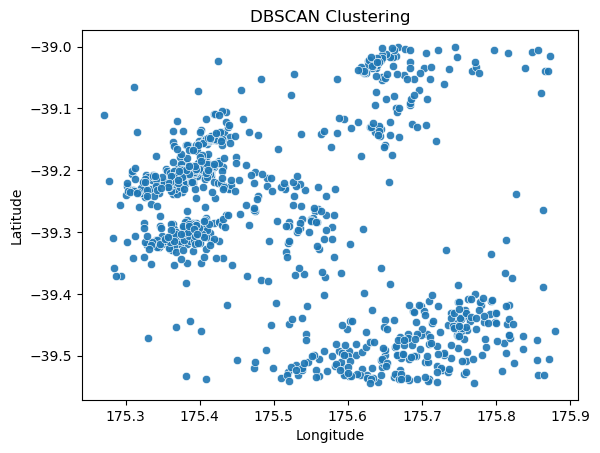

In [228]:
# Plot the clusters with different colors
sns.scatterplot(x=df['longitude'], y=df['latitude'], alpha=0.9)
# Plot the noise points in grey
# Set the x and y axis labels
plt.xlabel('Longitude')
plt.ylabel('Latitude')
# Set the title of the plot
plt.title('DBSCAN Clustering')
# Show the plot
plt.show()


0.06999999999999999
1.3163248377005214


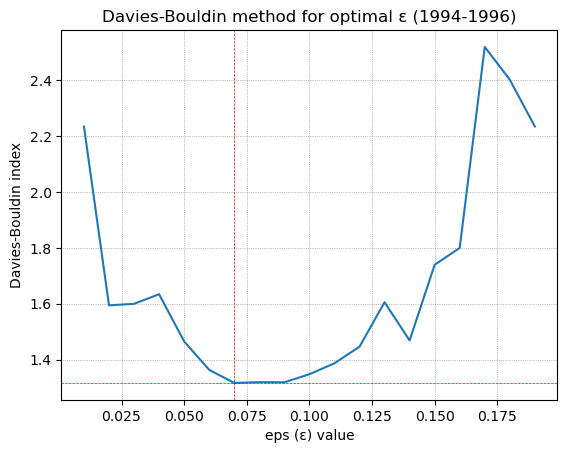

In [229]:
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics.pairwise import cosine_distances

#Now we set a range of eps values to find the optimal paramerters

# set the range of eps values to explore
eps_range = np.arange(0.01, 0.2, 0.01)
min_samples = 5

# initialize empty lists to store silhouette scores and Davies-Bouldin values
scores = []


# Try different values of eps
for eps in np.linspace(eps_range[0], eps_range[-1], len(eps_range)):
    # Create a DBSCAN instance with the current value of eps
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    # Fit the model to the data
    dbscan.fit(X)
    # Calculate the Davies-Bouldin index for this model
    try:
        if davies_bouldin_score(X, dbscan.labels_) >=1:
            score = davies_bouldin_score(X, dbscan.labels_)
        else:
            pass
    except:
        pass
    scores.append(score)
    


# Find the index of the minimum score
min_index = None

if scores.index(min(scores)) >= 1:
    min_index = scores.index(min(scores))

# The optimal eps value is the one at the same index in the eps array
eps_opt_dbi = np.linspace(eps_range[0], eps_range[-1], len(eps_range))[min_index]

print(eps_opt_dbi)
print(min(scores))
    
# Plot the scores against the eps values
plt.plot(np.linspace(eps_range[0], eps_range[-1], len(eps_range)), scores)
plt.title(f'Davies-Bouldin method for optimal ε ({start_year}-{end_year})')
plt.xlabel("eps (ε) value")
plt.ylabel('Davies-Bouldin index')
plt.axhline(min(scores), color='red', linestyle='--', linewidth='0.5')
plt.axvline(eps_opt_dbi, color='red', linestyle='--', linewidth='0.5')
plt.grid(which='both', linestyle=':', linewidth='0.5', color='gray')

plt.show()


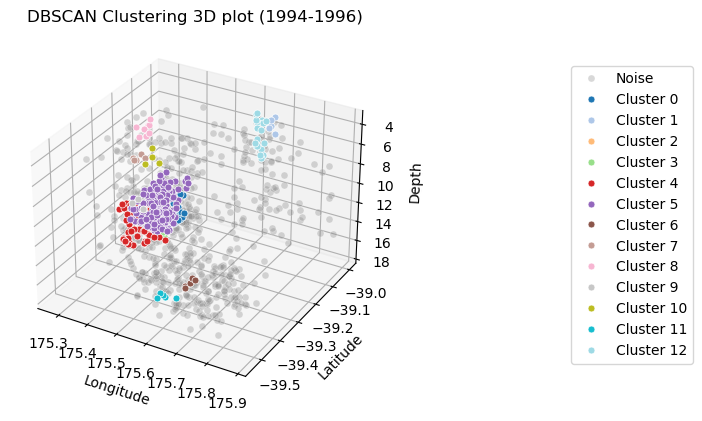

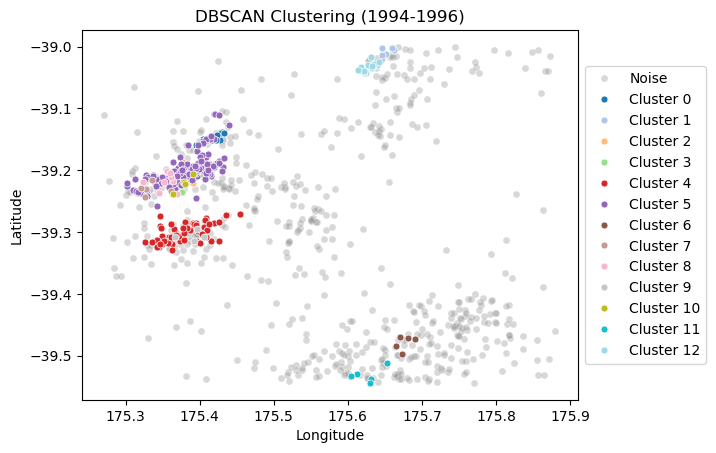

Number of samples: 5
Number of clusters: 13
Number of points in each cluster:
cluster
-1     622
 0      17
 1       5
 2       6
 3       9
 4      57
 5     190
 6       5
 7       5
 8       8
 9       4
 10      4
 11      5
 12     18
dtype: int64


In [243]:
#DBSCAN using davies_bouldin_score opt_eps

#run DBSCAN
dbscan = DBSCAN(eps=eps_opt_dbi, min_samples=min_samples)
#dbscan = DBSCAN(eps=0.07, min_samples=min_samples)
df['cluster'] = dbscan.fit_predict(X)


cmap = cm.get_cmap('tab20')
# plot clusters in 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# Plot each cluster with a different color

# Plot each cluster with a different color
for label in df['cluster'].unique():
    if label == -1:
        # Plot noise points in gray
        mask = (df['cluster'] == label)
        ax.plot(df.loc[mask, 'longitude'], df.loc[mask, 'latitude'], df.loc[mask, 'depth'], 'o', color='gray', 
                markeredgecolor='white', markeredgewidth=0.5, markersize=5, alpha=0.3, label='Noise')
    else:
        # Plot clustered points with color from colormap
        mask = (df['cluster'] == label)
        cluster_color = cmap(label / df['cluster'].max())
        ax.plot(df.loc[mask, 'longitude'], df.loc[mask, 'latitude'], df.loc[mask, 'depth'], 'o', color=cluster_color,
                markeredgecolor='white', markeredgewidth=0.5, markersize=5, label=f'Cluster {label}')
              
# Invert the z-axis
ax.invert_zaxis()

ax.legend(loc='center left', bbox_to_anchor=(1.5, 0.5))
# Set the title of the plot
plt.title(f'DBSCAN Clustering 3D plot ({start_year}-{end_year})')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Depth')
plt.show()



fig = plt.figure()
ax = fig.add_subplot(111)
# Plot each cluster with a different color
for label in df['cluster'].unique():
    if label == -1:
        # Plot noise points in gray
        mask = (df['cluster'] == label)
        ax.plot(df.loc[mask, 'longitude'], df.loc[mask, 'latitude'], 'o', color='gray', 
                markeredgecolor='white', markeredgewidth=0.5, markersize=5, alpha=0.3, label='Noise')
    else:
        # Plot clustered points with color from colormap
        mask = (df['cluster'] == label)
        cluster_color = cmap(label / df['cluster'].max())
        ax.plot(df.loc[mask, 'longitude'], df.loc[mask, 'latitude'], 'o', color=cluster_color, 
                markeredgecolor='white', markeredgewidth=0.5, markersize=5, label=f'Cluster {label}')
        
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# Set the title of the plot
plt.title(f'DBSCAN Clustering ({start_year}-{end_year})')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()



# Print the number of clusters and the number of points in each cluster
n_clusters = len(set(df['cluster'])) - (1 if -1 in df['cluster'].values else 0)
print(f"Number of samples: {min_samples}")
print(f"Number of clusters: {n_clusters}")
print("Number of points in each cluster:")
print(df.groupby('cluster').size())

In [244]:
#Check the maximum distance between two points in each cluster using davies_bouldin_score opt_eps
from sklearn.metrics.pairwise import haversine_distances
from math import radians

def max_cluster_distance(df, cluster_label):
    # get all points in the cluster
    cluster_points = df[df['cluster'] == cluster_label][['latitude', 'longitude']]

    # convert the coordinates from degrees to radians
    cluster_points = np.radians(cluster_points)

    # calculate pairwise distances between all points in the cluster using the haversine distance metric
    distances = haversine_distances(cluster_points)

    # find the maximum distance between two points in the cluster in kilometers
    max_distance = np.max(distances) * 6371.01

    return max_distance

# find the maximum distance in each cluster
max_distances = {}
for cluster_label in set(df['cluster']):
    if cluster_label != -1:  # exclude points not assigned to a cluster
        max_distances[cluster_label] = max_cluster_distance(df, cluster_label)

print(max_distances)

{0: 3.934026943291178, 1: 1.7567208124971263, 2: 4.471102720904478, 3: 4.711180581341352, 4: 12.138508697315851, 5: 18.017838664746698, 6: 3.1248076375195573, 7: 3.6276822715202406, 8: 4.486710625441517, 9: 3.29484924286833, 10: 4.254209246618219, 11: 4.757429162759894, 12: 3.037447787960633}


In [245]:
#Check the maximum distance between two points for the depth parameter
from sklearn.metrics.pairwise import euclidean_distances

def max_cluster_distance(df, cluster_label):
    # get all points in the cluster
    cluster_points = df[df['cluster'] == cluster_label][['depth']]

    # calculate pairwise distances between all points in the cluster
    distances = euclidean_distances(cluster_points)

    # find the maximum distance between two points in the cluster
    max_depths = np.max(distances)

    return max_depths


# find the maximum distance in each cluster
max_depths = {}
for cluster_label in set(df['cluster']):
    if cluster_label != -1:  # exclude points not assigned to a cluster
        max_depths[cluster_label] = max_cluster_distance(df, cluster_label)

        
print(max_depths)

{0: 3.299999999999998, 1: 1.79, 2: 1.0400000000000043, 3: 1.8100000000000038, 4: 4.330000000000003, 5: 6.300000000000004, 6: 0.9700000000000142, 7: 0.6700000000000067, 8: 1.4399999999999997, 9: 1.229999999999995, 10: 1.6599999999999981, 11: 0.6900000000000017, 12: 4.449999999999998}


In [253]:
#Number of days for each cluster

def max_cluster_duration(df, cluster_label):
    # get all points in the cluster
    cluster_points = df[df['cluster'] == cluster_label][['latitude', 'longitude', 'depth', 'time', 'date', 'cluster']]

    cluster_points['date'] = pd.to_datetime(cluster_points['date'])
    
    # calculate the minimum and maximum timestamps in the cluster
    min_date = np.min(cluster_points['date']).date()
    max_date = np.max(cluster_points['date']).date()

    # calculate the duration in days between the minimum and maximum timestamps
    duration_days = (max_date - min_date).days

    return duration_days, min_date, max_date

                                                        
                                                        
# find the duration in days of each cluster
cluster_durations = {}
min_dates = {}
max_dates = {}
for cluster_label in set(df['cluster']):
    if cluster_label != -1:  # exclude points not assigned to a cluster
        #cluster_durations[cluster_label] = max_cluster_duration(df, cluster_label)
        duration, min_date, max_date = max_cluster_duration(df, cluster_label)
        cluster_durations[cluster_label] = duration
        min_dates[cluster_label] = min_date
        max_dates[cluster_label] = max_date

print(cluster_durations)



{0: 79, 1: 27, 2: 29, 3: 56, 4: 119, 5: 252, 6: 47, 7: 41, 8: 63, 9: 18, 10: 21, 11: 10, 12: 1}


In [266]:
def cluster_centroids(df):
    # get all unique cluster labels, excluding -1
    cluster_labels = set(df['cluster']) - {-1}

    # initialize an empty dictionary to store the centroids
    centroids = {}

    # loop over each cluster label
    for label in cluster_labels:
        # select all points in the cluster
        cluster_points = df[df['cluster'] == label][['latitude', 'longitude']]
        # calculate the mean latitude and longitude of the cluster
        centroid = (cluster_points['latitude'].mean(), cluster_points['longitude'].mean())
        # store the centroid in the dictionary
        centroids[label] = centroid

    return centroids

# find the centroid of each cluster
centroids = cluster_centroids(df)

print(centroids)

{0: (-39.14854352941176, 175.4160076470588), 1: (-39.006941999999995, 175.65328000000002), 2: (-39.20577, 175.39505166666666), 3: (-39.21039555555555, 175.40170555555554), 4: (-39.30180140350877, 175.3780936842105), 5: (-39.20063084210527, 175.38215605263156), 6: (-39.47919, 175.676058), 7: (-39.230168, 175.334474), 8: (-39.2183975, 175.35418875), 9: (-39.306415, 175.39052750000002), 10: (-39.2210975, 175.37849), 11: (-39.531040000000004, 175.62621399999998), 12: (-39.033632222222224, 175.6269188888889)}


In [267]:
# create a DataFrame with the maximum distance and cluster centers
df_cluster_info = pd.DataFrame({'cluster_distance (km)': max_distances.values(),
                                'cluster_depth (km)': max_depths.values(),
                                'cluster_duration (days)': cluster_durations.values(),
                                'start_date': min_dates.values(),
                                'end_date': max_dates.values(),
                                'cluster_centroid': centroids.values()
                               }
                              )


df_cluster_info['cluster_number'] = df_cluster_info.index

df_cluster_info = df_cluster_info[['cluster_number', 'start_date', 'end_date', 'cluster_duration (days)', 
                                   'cluster_distance (km)', 'cluster_depth (km)', 'cluster_centroid']]

df_cluster_info

,cluster_number,start_date,end_date,cluster_duration (days),cluster_distance (km),cluster_depth (km),cluster_centroid
0,0,1994-04-25,1994-07-13,79,3.934027,3.30,"(-39.14854352941176, 175.4160076470588)"
1,1,1994-06-12,1994-07-09,27,1.756721,1.79,"(-39.006941999999995, 175.65328000000002)"
2,2,1994-06-14,1994-07-13,29,4.471103,1.04,"(-39.20577, 175.39505166666666)"
3,3,1994-06-16,1994-08-11,56,4.711181,1.81,"(-39.21039555555555, 175.40170555555554)"
4,4,1994-11-28,1995-03-27,119,12.138509,4.33,"(-39.30180140350877, 175.3780936842105)"
5,5,1994-12-31,1995-09-09,252,18.017839,6.30,"(-39.20063084210527, 175.38215605263156)"
6,6,1995-02-10,1995-03-29,47,3.124808,0.97,"(-39.47919, 175.676058)"
7,7,1995-02-21,1995-04-03,41,3.627682,0.67,"(-39.230168, 175.334474)"
8,8,1995-03-06,1995-05-08,63,4.486711,1.44,"(-39.2183975, 175.35418875)"
9,9,1995-03-27,1995-04-14,18,3.294849,1.23,"(-39.306415, 175.39052750000002)"


In [268]:
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

geolocator = Nominatim(user_agent="http")

# create an empty DataFrame to store the results
result_df = pd.DataFrame(columns=['latitude', 'longitude', 'address'])

print(centroids)



{0: (-39.14854352941176, 175.4160076470588), 1: (-39.006941999999995, 175.65328000000002), 2: (-39.20577, 175.39505166666666), 3: (-39.21039555555555, 175.40170555555554), 4: (-39.30180140350877, 175.3780936842105), 5: (-39.20063084210527, 175.38215605263156), 6: (-39.47919, 175.676058), 7: (-39.230168, 175.334474), 8: (-39.2183975, 175.35418875), 9: (-39.306415, 175.39052750000002), 10: (-39.2210975, 175.37849), 11: (-39.531040000000004, 175.62621399999998), 12: (-39.033632222222224, 175.6269188888889)}


In [269]:

# loop through the dictionary and find the closest town for each set of coordinates
for idx, centroids in centroids.items():
    latitude, longitude = centroids
    
    # find the nearest location using geopy
    location = geolocator.reverse((latitude, longitude), exactly_one=True)
    
    address = location.raw['address']
    
    # add the result to the DataFrame
    result_df.loc[idx] = [latitude, longitude, address]


    

     latitude   longitude                                            address
0  -39.148544  175.416008  {'village': 'National Park', 'county': 'Ruapeh...
1  -39.006942  175.653280  {'road': 'Access Road Number 5', 'county': 'Ta...
2  -39.205770  175.395052  {'road': 'Erua Tramway Trail', 'hamlet': 'Waik...
3  -39.210396  175.401706  {'road': 'State Highway 4', 'hamlet': 'Waikune...
4  -39.301801  175.378094  {'locality': 'Pokaka', 'county': 'Ruapehu Dist...
5  -39.200631  175.382156  {'road': 'Marton Sash and Door Trail', 'county...
6  -39.479190  175.676058  {'leisure': 'Waiouru Rugby Club', 'road': 'Has...
7  -39.230168  175.334474  {'county': 'Ruapehu District', 'state': 'Manaw...
8  -39.218398  175.354189  {'road': 'Cuff Road', 'county': 'Ruapehu Distr...
9  -39.306415  175.390528  {'road': 'State Highway 4', 'hamlet': 'Horopit...
10 -39.221097  175.378490  {'road': 'Marton Sash and Door Trail', 'county...
11 -39.531040  175.626214  {'county': 'Rangitīkei District', 'state': 'Ma...

In [270]:
# print the result
result_df

,latitude,longitude,address
0,-39.148544,175.416008,"{'village': 'National Park', 'county': 'Ruapeh..."
1,-39.006942,175.653280,"{'road': 'Access Road Number 5', 'county': 'Ta..."
2,-39.205770,175.395052,"{'road': 'Erua Tramway Trail', 'hamlet': 'Waik..."
3,-39.210396,175.401706,"{'road': 'State Highway 4', 'hamlet': 'Waikune..."
4,-39.301801,175.378094,"{'locality': 'Pokaka', 'county': 'Ruapehu Dist..."
5,-39.200631,175.382156,"{'road': 'Marton Sash and Door Trail', 'county..."
6,-39.479190,175.676058,"{'leisure': 'Waiouru Rugby Club', 'road': 'Has..."
7,-39.230168,175.334474,"{'county': 'Ruapehu District', 'state': 'Manaw..."
8,-39.218398,175.354189,"{'road': 'Cuff Road', 'county': 'Ruapehu Distr..."
9,-39.306415,175.390528,"{'road': 'State Highway 4', 'hamlet': 'Horopit..."


In [273]:
df_merged = df_cluster_info.merge(result_df, left_index=True, right_index=True, how='inner') 

df_merged.to_csv(r'C:\Users\qdr22hqu\OneDrive - University of East Anglia\Documents\NZ EQ Clusters Ruapehu\results.csv')

